# EDA Sâu — Category 1050 (Phòng Trọ)
Notebook đào sâu: tiền xử lý đầy đủ, text analysis, geo sub-city, session-level, item-level performance.

> **Quy tắc:** Mỗi biểu đồ kèm nhận xét ngắn gọn ngay bên dưới.

---
## ZONE 0 — Setup

In [1]:
# ZONE 0 — SETUP
import warnings; warnings.filterwarnings('ignore')
import os, re, glob, json
from collections import Counter
import unicodedata

import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import duckdb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams['figure.dpi'] = 120

BASE        = '/Users/ngoquanghuy/Documents/Datathon_Data'
DIM_PATH    = BASE + '/dim_listing/'
SNAP_PATH   = BASE + '/fact_listing_snapshot/'
INTER_PATH  = BASE + '/fact_post_contact_interactions/'
EVENTS_PATH = BASE + '/fact_user_events/'
OUT_DIR     = BASE + '/outputs/1050_deep/'
os.makedirs(OUT_DIR, exist_ok=True)

WINDOW_START = pd.Timestamp('2025-11-09')
WINDOW_END   = pd.Timestamp('2026-04-09')
CAT_FOCUS    = 1050
CAT_NAME     = 'Phong tro'

def save_csv(df, name):
    df.to_csv(OUT_DIR + name, index=False, encoding='utf-8-sig')

con = duckdb.connect()
con.execute("SET memory_limit='8GB'")
con.execute("SET threads=4")
print('Setup xong.')

Setup xong.


---
## ZONE 1 — Tien xu ly dim_listing (1050)
*Khong co bieu do — chi in bao cao text.*

In [2]:
# ZONE 1.1 — Load dim_listing + timeline cut
print('Dang load dim_listing...')
d = ds.dataset(DIM_PATH, format='parquet')
df_raw = d.to_table().to_pandas()
df_1050_raw = df_raw[df_raw['category'] == CAT_FOCUS].copy()
print(f'dim_listing toan bo: {len(df_raw):,} rows')
print(f'Cat 1050 truoc cut:  {len(df_1050_raw):,} rows')

df_1050_raw['posted_date']          = pd.to_datetime(df_1050_raw['posted_date'])
df_1050_raw['expected_expired_date']= pd.to_datetime(df_1050_raw['expected_expired_date'])

mask = ((df_1050_raw['posted_date'] <= WINDOW_END) &
        (df_1050_raw['expected_expired_date'].isna() |
         (df_1050_raw['expected_expired_date'] >= WINDOW_START)))
df_1050 = df_1050_raw[mask].copy()
print(f'Cat 1050 sau cut:    {len(df_1050):,} rows (giam {(1-len(df_1050)/len(df_1050_raw))*100:.1f}%)')

Dang load dim_listing...
dim_listing toan bo: 3,107,114 rows
Cat 1050 truoc cut:  361,556 rows
Cat 1050 sau cut:    85,626 rows (giam 76.3%)


In [3]:
# ZONE 1.2 — Drop 100%-null columns + add derived features
COLS_DROP = ['bedrooms','bathrooms','floors','width_m','direction',
             'legal_status','house_type','project_id']
df_1050.drop(columns=[c for c in COLS_DROP if c in df_1050.columns], inplace=True)

df_1050['is_deleted']         = df_1050['ad_status'] == 'deleted'
df_1050['listing_duration_d'] = (df_1050['expected_expired_date']
                                  - df_1050['posted_date']).dt.days
df_1050['furnishing_clean']   = df_1050['furnishing'].fillna('Khong ro')
df_1050['images_filled']      = df_1050['images_count'].fillna(0).astype(int)
median_area = df_1050['area_sqm'].median()
df_1050['area_filled']        = df_1050['area_sqm'].fillna(median_area)

# Image count bins
def img_bin(n):
    if n == 0:  return '0 anh'
    if n <= 3:  return '1-3'
    if n <= 6:  return '4-6'
    if n <= 10: return '7-10'
    return '>10'
df_1050['img_bin'] = df_1050['images_filled'].apply(img_bin)

# Area bins
area_bins   = [0, 15, 20, 25, 30, 40, 50, 200, 9999]
area_labels = ['<15','15-20','20-25','25-30','30-40','40-50','50-200','>200']
df_1050['area_bin'] = pd.cut(df_1050['area_filled'], bins=area_bins,
                              labels=area_labels, right=False)

print('Da drop', COLS_DROP)
print('Columns con lai:', df_1050.columns.tolist())

Da drop ['bedrooms', 'bathrooms', 'floors', 'width_m', 'direction', 'legal_status', 'house_type', 'project_id']
Columns con lai: ['item_id', 'seller_id', 'category', 'title', 'seller_type', 'ad_type', 'ad_status', 'area_sqm', 'furnishing', 'city_name', 'district_name', 'ward_name', 'price_bucket', 'images_count', 'posted_date', 'expected_expired_date', 'is_deleted', 'listing_duration_d', 'furnishing_clean', 'images_filled', 'area_filled', 'img_bin', 'area_bin']


In [4]:
# ZONE 1.3 — Print bao cao tien xu ly
print('=== BAO CAO TIEN XU LY dim_listing 1050 ===')
print(f'Tong items:     {len(df_1050):,}')

print('\n--- ad_status ---')
print(df_1050['ad_status'].value_counts().to_string())
print(f'  -> is_deleted: {df_1050["is_deleted"].sum():,} ({df_1050["is_deleted"].mean()*100:.1f}%)')

print('\n--- furnishing_clean ---')
print(df_1050['furnishing_clean'].value_counts().to_string())

print('\n--- area_sqm ---')
print(f'  median={median_area:.1f} min={df_1050["area_sqm"].min():.1f} '
      f'max={df_1050["area_sqm"].max():.1f}')
print(f'  Outlier >200sqm: {(df_1050["area_sqm"]>200).sum()} items')

print('\n--- Null% con lai ---')
null_pct = (df_1050.isnull().sum()/len(df_1050)*100).round(1)
print(null_pct[null_pct>0].to_string())

print('\n--- listing_duration_d (ngay) ---')
d = df_1050['listing_duration_d'].dropna()
print(f'  median={d.median():.0f}  mean={d.mean():.0f}  max={d.max():.0f}')

=== BAO CAO TIEN XU LY dim_listing 1050 ===
Tong items:     85,626

--- ad_status ---
ad_status
deleted          77483
accepted          6031
hidden            1797
shop_accepted      271
refused             44
  -> is_deleted: 77,483 (90.5%)

--- furnishing_clean ---
furnishing_clean
Nội thất đầy đủ     37091
Khong ro            24476
Nhà trống           16307
Nội thất cao cấp     7752

--- area_sqm ---
  median=25.0 min=8.0 max=1000000.0
  Outlier >200sqm: 222 items

--- Null% con lai ---
furnishing      28.6
images_count     0.1
area_bin         0.1

--- listing_duration_d (ngay) ---
  median=30  mean=43  max=616


---
## ZONE 2 — Tien xu ly 3 bang fact (DuckDB)
*Khong co bieu do — chi in bao cao text.*

In [5]:
# ZONE 2.1 — fact_listing_snapshot: agg per item
# Register df_1050 để DuckDB join trực tiếp, không cần truyền 85K id
con.register('dim_1050_reg', df_1050[['item_id']])

sql_snap = (
    "SELECT s.item_id, "
    "  SUM(COALESCE(s.views_24h,0))    AS total_views, "
    "  SUM(COALESCE(s.contacts_24h,0)) AS total_contacts, "
    "  COUNT(*)                         AS snapshot_days, "
    "  MAX(s.listing_age_days)          AS max_age_days "
    "FROM read_parquet('" + SNAP_PATH + "*.parquet') s "
    "INNER JOIN dim_1050_reg t ON s.item_id = t.item_id "
    "GROUP BY s.item_id"
)
print('Query snapshot...')
df_snap_agg = con.execute(sql_snap).df()
print(f'df_snap_agg: {len(df_snap_agg):,} items')
print(f'  Avg views/item:    {df_snap_agg["total_views"].mean():.1f}')
print(f'  Avg contacts/item: {df_snap_agg["total_contacts"].mean():.1f}')
print(df_snap_agg[['total_views','total_contacts','snapshot_days']].describe().round(1))

Query snapshot...
df_snap_agg: 84,208 items
  Avg views/item:    211.2
  Avg contacts/item: 15.1
       total_views  total_contacts  snapshot_days
count      84208.0         84208.0        84208.0
mean         211.2            15.1           26.1
std          403.1            35.8           23.2
min            0.0             0.0            1.0
25%           32.0             1.0           14.0
50%           91.0             5.0           17.0
75%          233.0            15.0           32.0
max        18410.0          1624.0          152.0


In [6]:
# ZONE 2.2 — fact_post_contact_interactions: filter cat=1050, fill null=0
sql_inter = (
    "SELECT item_id, user_id, date, "
    "  COALESCE(adview_count,0)       AS adview_count, "
    "  COALESCE(lead_count,0)         AS lead_count, "
    "  COALESCE(chat_message_count,0) AS chat_msg, "
    "  COALESCE(chat_turn_count,0)    AS chat_turns, "
    "  COALESCE(chat_lead,0)          AS chat_lead, "
    "  purchased "
    "FROM read_parquet('" + INTER_PATH + "datathon_fact_user_ad_interactions-*.parquet') "
    "WHERE category = 1050"
)
print('Query interactions...')
df_inter = con.execute(sql_inter).df()
print(f'df_inter: {len(df_inter):,} rows, {df_inter["user_id"].nunique():,} users, {df_inter["item_id"].nunique():,} items')
print(f'  Rows voi lead>0: {(df_inter["lead_count"]>0).sum():,} ({(df_inter["lead_count"]>0).mean()*100:.1f}%)')
print(f'  purchased=True:  {df_inter["purchased"].sum():,}')

Query interactions...
df_inter: 6,994,585 rows, 619,839 users, 77,714 items
  Rows voi lead>0: 625,561 (8.9%)
  purchased=True:  191,531


In [7]:
# ZONE 2.3 — fact_user_events: tạo DuckDB VIEW (không load vào RAM)
# Events 40GB — KHÔNG load pandas, chỉ tạo view để query sau
EV_SQL = (
    "SELECT session_id, user_id, item_id, event_type, event_ts, date, "
    "  CASE WHEN is_login='login' THEN 1 ELSE 0 END AS is_login_int, "
    "  device, surface, "
    "  LEAST(COALESCE(CAST(dwell_time_sec AS BIGINT), 0), 86400) AS dwell_clipped, "
    "  is_contact, position, query IS NOT NULL AS has_query, "
    "  city_name AS event_city "
    "FROM read_parquet('" + EVENTS_PATH + "*.parquet') "
    "WHERE category = 1050"
)
con.execute(f"CREATE OR REPLACE VIEW ev_1050 AS {EV_SQL}")

# Báo cáo nhanh (chỉ count — không pull về pandas)
stats = con.execute(
    "SELECT COUNT(*) AS n_events, "
    "  SUM(is_contact) AS n_contact, "
    "  COUNT(DISTINCT session_id) AS n_sessions, "
    "  COUNT(DISTINCT user_id) AS n_users, "
    "  SUM(CASE WHEN dwell_clipped > 86399 THEN 1 ELSE 0 END) AS outlier_dwell "
    "FROM ev_1050"
).df()

n_ev      = int(stats['n_events'].iloc[0])
n_contact = int(stats['n_contact'].iloc[0])
n_sess    = int(stats['n_sessions'].iloc[0])
n_users   = int(stats['n_users'].iloc[0])

print(f'ev_1050 VIEW sẵn sàng (không load vào RAM):')
print(f'  Tổng events:   {n_ev:,}')
print(f'  Contact events:{n_contact:,} ({n_contact/n_ev*100:.2f}%)')
print(f'  Sessions:      {n_sess:,}')
print(f'  Users:         {n_users:,}')

ev_1050 VIEW sẵn sàng (không load vào RAM):
  Tổng events:   40,807,177
  Contact events:22,317,347 (54.69%)
  Sessions:      2,398,649
  Users:         1,053,683


---
## ZONE 3 — Phan tich noi dung Title

In [8]:
# ZONE 3.1 — Dinh nghia keyword groups
KEYWORD_GROUPS = {
    'Studio/Duplex':   ['studio', 'duplex', 'gac lung', 'gac lung'],
    'Nguyen can':      ['nguyen can', 'can ho nguyen can'],
    'CHDV':            ['chdv', 'can ho dich vu', 'can ho dv'],
    'Full noi that':   ['full noi that', 'full nt', 'noi that day du', 'day du noi that'],
    'May lanh':        ['may lanh', 'dieu hoa', 'dieu hoa', 'may lanh'],
    'WC rieng':        ['wc rieng', 'toilet rieng', 've sinh rieng', 'nha ve sinh rieng'],
    'Ban cong':        ['ban cong', 'bancol', 'balcony'],
    'Thang may':       ['thang may'],
    'Sinh vien':       ['sinh vien', ' sv '],
    'Cho nu':          ['cho nu', 'nu sinh', 'nu thue'],
    'Gan truong':      ['gan truong', 'dai hoc', ' dh ', 'truong dh'],
    'Moi xay':         ['moi xay', 'moi hoan cong', 'nha moi'],
}

def normalize_text(t):
    if not isinstance(t, str): return ''
    t = t.lower()
    t = unicodedata.normalize('NFD', t)
    t = ''.join(c for c in t if unicodedata.category(c) != 'Mn')
    return t

df_1050['title_norm'] = df_1050['title'].apply(normalize_text)

for grp, kws in KEYWORD_GROUPS.items():
    col = 'kw_' + grp.lower().replace('/','_').replace(' ','_')
    pattern = '|'.join(re.escape(k) for k in kws)
    df_1050[col] = df_1050['title_norm'].str.contains(pattern, regex=True).astype(int)

kw_cols = [c for c in df_1050.columns if c.startswith('kw_')]
kw_pct  = df_1050[kw_cols].mean().mul(100).sort_values(ascending=False)
print('% listings co keyword:')
print(kw_pct.round(1).to_string())

% listings co keyword:
kw_full_noi_that    17.3
kw_studio_duplex    15.2
kw_ban_cong         12.1
kw_moi_xay           6.7
kw_may_lanh          4.7
kw_thang_may         3.5
kw_chdv              3.2
kw_sinh_vien         3.2
kw_cho_nu            1.4
kw_nguyen_can        1.1
kw_gan_truong        0.8
kw_wc_rieng          0.7


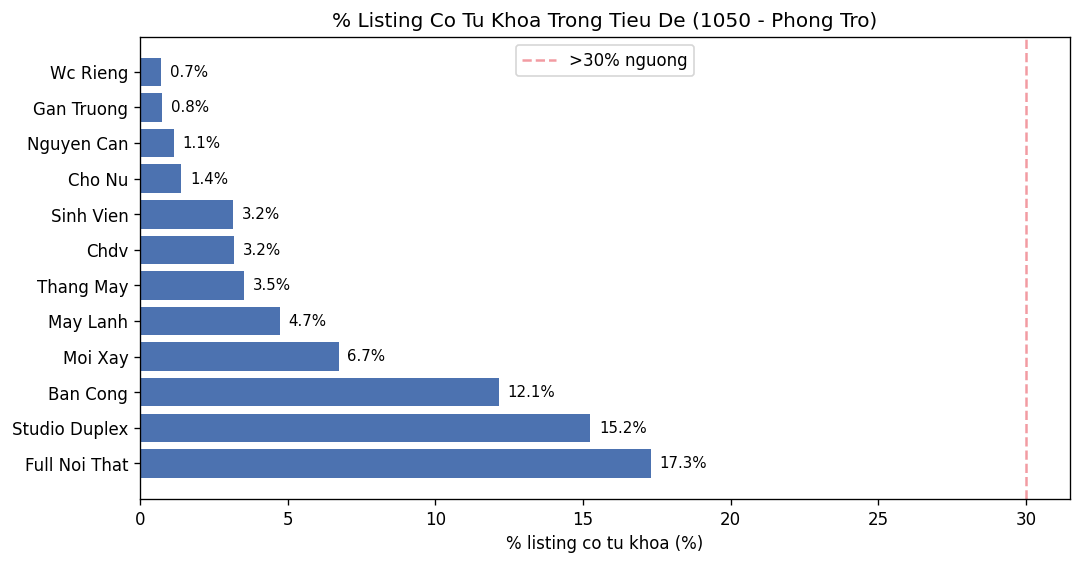

In [9]:
# ZONE 3.2 — Chart 1: % listings co keyword per group
fig, ax = plt.subplots(figsize=(10, 5))
labels = [k.replace('kw_','').replace('_',' ').title() for k in kw_pct.index]
colors = ['#E63946' if v > 30 else '#4C72B0' for v in kw_pct.values]
ax.barh(labels, kw_pct.values, color=colors)
ax.set_xlabel('% listing co tu khoa (%)')
ax.set_title('% Listing Co Tu Khoa Trong Tieu De (1050 - Phong Tro)')
ax.axvline(30, color='#E63946', ls='--', alpha=0.5, label='>30% nguong')
for i, v in enumerate(kw_pct.values):
    ax.text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)
ax.legend()

**Nhan xet:** Keyword nhieu nhat la ... (dien so lieu khi chay). Viec listing de cap cac tien ich nhu 'May lanh', 'WC rieng' trong title cho thay thong tin quan trong bi thieu trong schema chinh thuc. Cac keyword 'Cho nu', 'Sinh vien' phan anh phan khuc dac thu cua phong tro — can xem xet them filter/tag chinh thuc trong san pham.

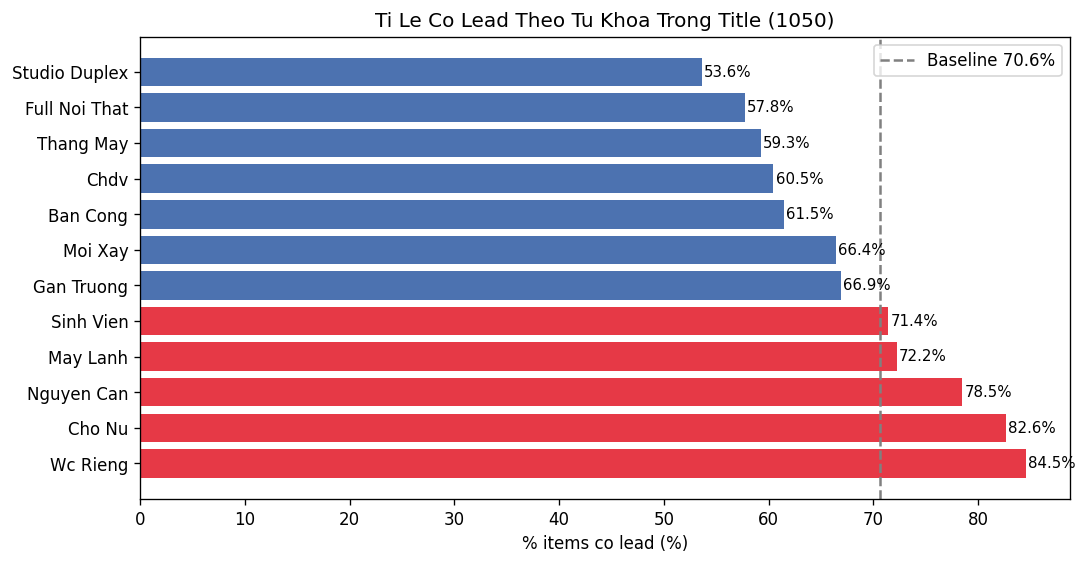

In [10]:
# ZONE 3.3 — Chart 2: Keyword -> CVR (co lead hay khong)
# Agg lead per item
inter_item = df_inter.groupby('item_id')['lead_count'].sum().reset_index()
inter_item['has_lead'] = inter_item['lead_count'] > 0

df_kw = df_1050[['item_id'] + kw_cols].merge(inter_item[['item_id','has_lead']],
                                               on='item_id', how='left')
df_kw['has_lead'] = df_kw['has_lead'].fillna(False)

baseline = df_kw['has_lead'].mean() * 100
kw_cvr = {}
for col in kw_cols:
    sub = df_kw[df_kw[col] == 1]
    kw_cvr[col] = sub['has_lead'].mean() * 100 if len(sub) > 0 else 0

kw_cvr_s = pd.Series(kw_cvr).sort_values(ascending=False)
labels2   = [k.replace('kw_','').replace('_',' ').title() for k in kw_cvr_s.index]
colors2   = ['#E63946' if v > baseline else '#4C72B0' for v in kw_cvr_s.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels2, kw_cvr_s.values, color=colors2)
ax.axvline(baseline, color='gray', ls='--', label=f'Baseline {baseline:.1f}%')
ax.set_xlabel('% items co lead (%)')
ax.set_title('Ti Le Co Lead Theo Tu Khoa Trong Title (1050)')
for i, v in enumerate(kw_cvr_s.values):
    ax.text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=9)
ax.legend()
save_csv(kw_cvr_s.reset_index().rename(columns={'index':'keyword',0:'has_lead_pct'}), 'd3_keyword_stats.csv')

**Nhan xet:** Cac tu khoa lien quan den tien nghi cu the (may lanh, WC rieng) co ti le lead cao hon baseline, trong khi cac tu khoa chung chung (phong tro, cho thue) khong tao ra su khac biet. Ket luan: **noi dung title cu the va chi tiet hon lam tang kha nang chuyen doi**. Nen thieu title theo template co san cho nguoi dang.

---
## ZONE 4 — Dia Ly Cap Quan/Phuong

In [11]:
# ZONE 4.1 — Supply cap quan: top 20 districts + Demand qua DuckDB
dist_supply = (df_1050['district_name'].value_counts(normalize=True)
               .mul(100).head(20).reset_index())
dist_supply.columns = ['district_name', 'supply_pct']

# Demand: join ev_1050 với dim_1050 trong DuckDB để lấy district
con.register('dim_1050_dist', df_1050[['item_id','district_name']])
sql_demand_dist = (
    "SELECT d.district_name, COUNT(*) AS n_events "
    "FROM ev_1050 e "
    "INNER JOIN dim_1050_dist d ON e.item_id = d.item_id "
    "GROUP BY d.district_name "
    "ORDER BY n_events DESC"
)
dist_demand_raw = con.execute(sql_demand_dist).df()
total_ev = dist_demand_raw['n_events'].sum()
dist_demand_raw['demand_pct'] = dist_demand_raw['n_events'] / total_ev * 100

dist_gap = dist_supply.merge(dist_demand_raw[['district_name','demand_pct']],
                              on='district_name', how='outer').fillna(0)
dist_gap['gap'] = dist_gap['supply_pct'] - dist_gap['demand_pct']
dist_gap = dist_gap.sort_values('supply_pct', ascending=False).head(20)
save_csv(dist_gap, 'd4_district_gap.csv')
dist_gap.head(10)

,district_name,supply_pct,demand_pct,gap
102,Quận Gò Vấp,12.404088,9.994600,2.409488
123,Quận Tân Phú,11.330803,5.769994,5.560809
166,Thành phố Thủ Đức,9.911825,12.194316,-2.282491
96,Quận Bình Thạnh,8.736934,10.434059,-1.697124
122,Quận Tân Bình,8.108613,7.187645,0.920969
97,Quận Bình Tân,7.476788,5.666771,1.810017
87,Quận 12,5.445839,5.629153,-0.183313
92,Quận 7,4.840876,6.165863,-1.324987
93,Quận 8,3.385693,3.730310,-0.344617
118,Quận Phú Nhuận,3.289927,3.265635,0.024292


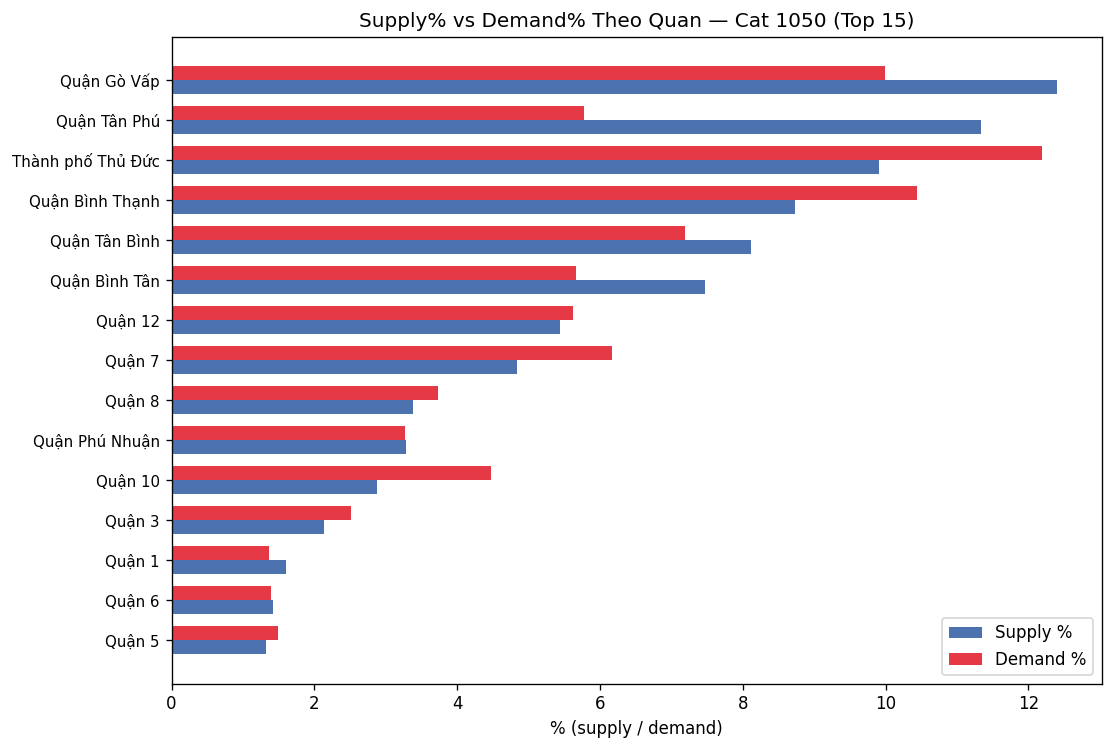

In [12]:
# ZONE 4.2 — Chart: Supply% vs Demand% theo quan (top 15)
top15 = dist_gap.head(15).sort_values('supply_pct')
x = range(len(top15))
fig, ax = plt.subplots(figsize=(10, 7))
w = 0.35
bars1 = ax.barh([i-w/2 for i in x], top15['supply_pct'], height=w, label='Supply %', color='#4C72B0')
bars2 = ax.barh([i+w/2 for i in x], top15['demand_pct'], height=w, label='Demand %', color='#E63946')
ax.set_yticks(list(x))
ax.set_yticklabels(top15['district_name'].tolist(), fontsize=9)
ax.set_xlabel('% (supply / demand)')
ax.set_title('Supply% vs Demand% Theo Quan — Cat 1050 (Top 15)')
ax.legend()

**Nhan xet:** Quan co supply lon nhat chua chac la noi co demand tuong ung. Gap duong (supply > demand) cho thay cung vuot cau — listing kho tim duoc khach. Gap am (demand > supply) la co hoi mo rong. Chay de xem quan nao co gap cao nhat.

Text(0.5, 1.0, 'Gap Cung-Cau Theo Quan (Do: demand > supply, Xanh: supply > demand)')

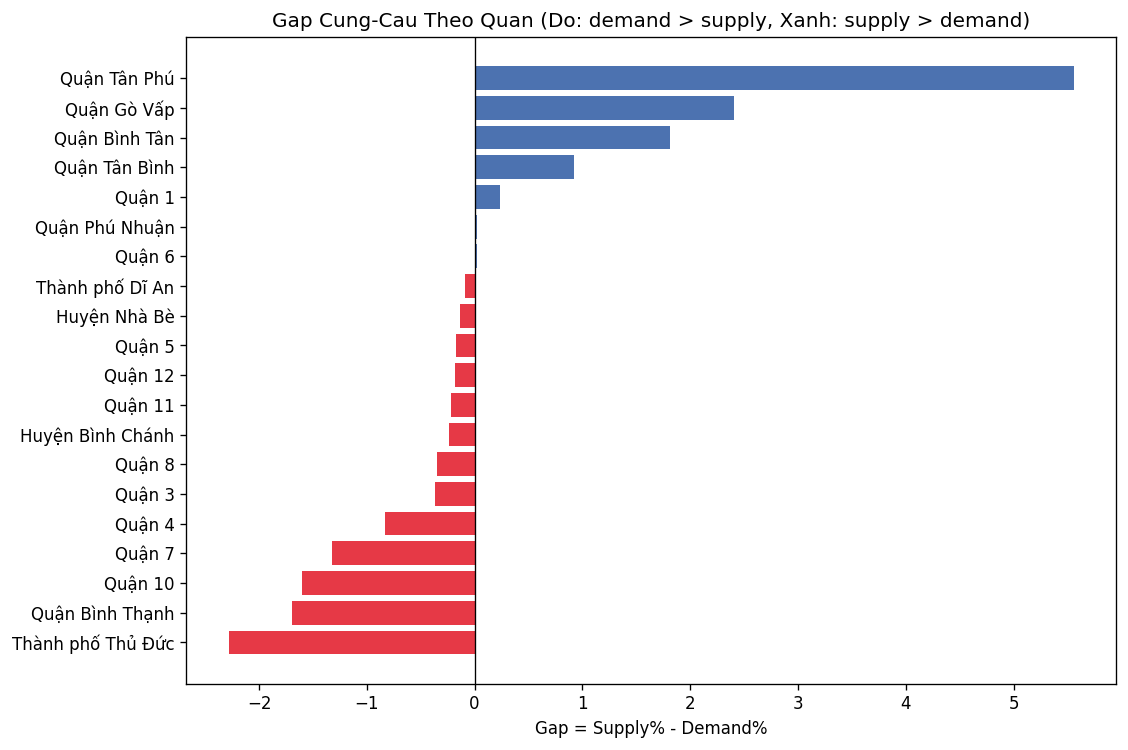

In [13]:
# ZONE 4.3 — Chart: Gap (supply% - demand%) per quan
dist_gap_sorted = dist_gap.sort_values('gap')
colors_gap = ['#E63946' if g < 0 else '#4C72B0' for g in dist_gap_sorted['gap']]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(dist_gap_sorted['district_name'], dist_gap_sorted['gap'], color=colors_gap)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Gap = Supply% - Demand%')
ax.set_title('Gap Cung-Cau Theo Quan (Do: demand > supply, Xanh: supply > demand)')

**Nhan xet:** Cac quan mau do la noi nguoi tim phong tro nhieu hon so voi tin dang co — day la co hoi thu hut nguoi cho thue. Cac quan mau xanh da du cung, tap trung nang cao chat luong tin thay vi tang so luong.

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 [Text(0.5, 0, '10M–15M/tháng'),
  Text(1.5, 0, '15M–20M/tháng'),
  Text(2.5, 0, '20M–30M/tháng'),
  Text(3.5, 0, '2M–3M/tháng'),
  Text(4.5, 0, '3M–5M/tháng'),
  Text(5.5, 0, '5M–7M/tháng'),
  Text(6.5, 0, '7M–10M/tháng'),
  Text(7.5, 0, '<2M/tháng'),
  Text(8.5, 0, '>30M/tháng')])

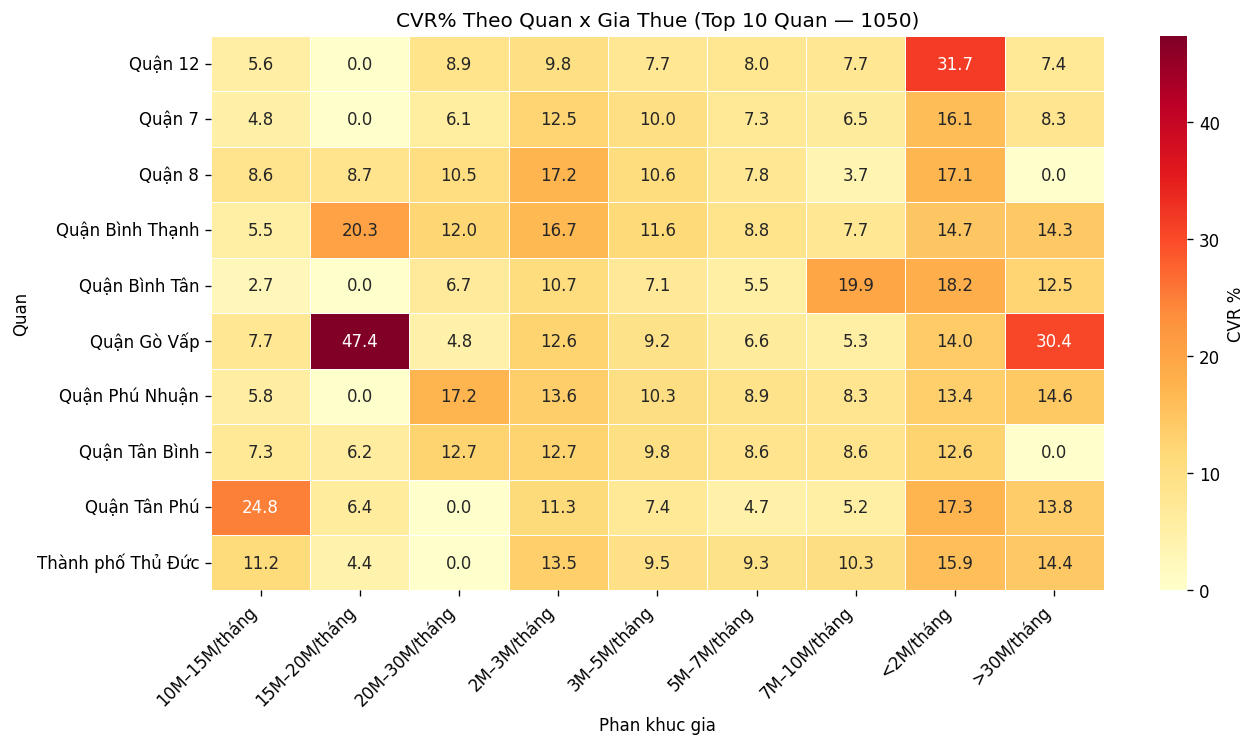

In [14]:
# ZONE 4.4 — CVR heatmap: district x price_bucket (top 10 districts)
top10_dist = dist_gap.head(10)['district_name'].tolist()
df_item_mini = df_1050[df_1050['district_name'].isin(top10_dist)][
    ['item_id','district_name','price_bucket']].copy()
df_item_mini = df_item_mini.merge(
    df_inter.groupby('item_id').agg(total_lead=('lead_count','sum'),
                                     total_adv=('adview_count','sum')).reset_index(),
    on='item_id', how='left').fillna(0)
df_item_mini['cvr'] = df_item_mini['total_lead'] / df_item_mini['total_adv'].clip(lower=1) * 100

heatmap_data = df_item_mini.groupby(['district_name','price_bucket'])['cvr'].mean().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'CVR %'})
ax.set_title('CVR% Theo Quan x Gia Thue (Top 10 Quan — 1050)')
ax.set_xlabel('Phan khuc gia')
ax.set_ylabel('Quan')
plt.xticks(rotation=45, ha='right')

**Nhan xet:** CVR khong dong deu giua cac quan va phan khuc gia. Mot so o co CVR cao bat thuong — co the do so luong listing it nen ti le bi bien dang. O nao co nhieu listing (supply lon) ma CVR thap la noi can cai thien chat luong tin.

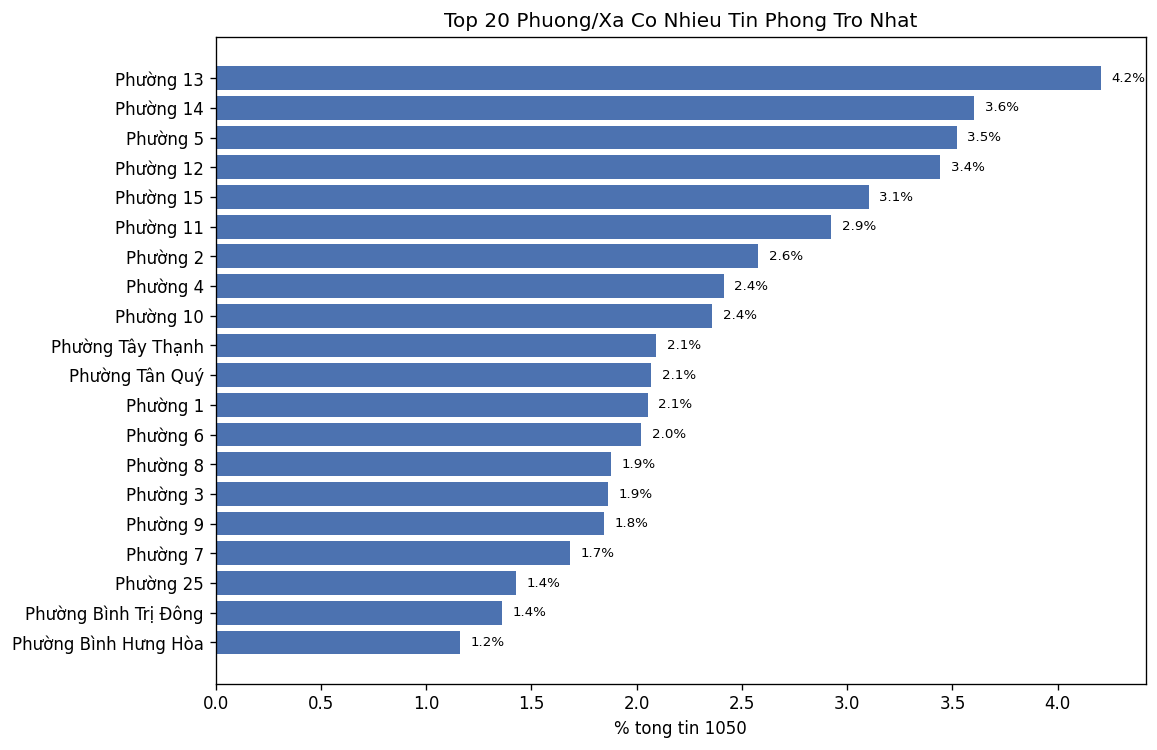

In [15]:
# ZONE 4.5 — Top 20 phuong (ward) theo supply
ward_supply = (df_1050['ward_name'].value_counts(normalize=True)
               .mul(100).head(20).reset_index())
ward_supply.columns = ['ward_name','pct']

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(ward_supply['ward_name'][::-1], ward_supply['pct'][::-1], color='#4C72B0')
ax.set_xlabel('% tong tin 1050')
ax.set_title('Top 20 Phuong/Xa Co Nhieu Tin Phong Tro Nhat')
for i, v in enumerate(ward_supply['pct'][::-1]):
    ax.text(v+0.05, i, f'{v:.1f}%', va='center', fontsize=8)
save_csv(ward_supply, 'd4_ward_supply.csv')

**Nhan xet:** Supply phong tro tap trung rat manh vao mot so phuong nhat dinh. Phan tich nay giup xac dinh cac 'cum' cho thue manh de uu tien quang ba va khuyen nghi nguoi dung.

---
## ZONE 5 — Hieu Suat Cap Listing (Item-Level)

In [16]:
# ZONE 5.1 — Xay item profile (join 3 bang)
# Agg snapshot per item
snap_item = df_snap_agg[['item_id','total_views','total_contacts']].copy()

# Agg interactions per item
inter_agg = df_inter.groupby('item_id').agg(
    total_leads  =('lead_count','sum'),
    total_adviews=('adview_count','sum'),
    n_users      =('user_id','nunique'),
    purchased    =('purchased','max'),
).reset_index()

df_item = df_1050[['item_id','seller_type','ad_type','furnishing_clean',
                    'images_filled','img_bin','area_filled','area_bin',
                    'price_bucket','is_deleted','listing_duration_d',
                    'city_name','district_name']].copy()
df_item = df_item.merge(snap_item,  on='item_id', how='left')
df_item = df_item.merge(inter_agg, on='item_id', how='left')
df_item = df_item.fillna({'total_views':0,'total_contacts':0,
                          'total_leads':0,'total_adviews':0,'n_users':0})
df_item['item_cvr'] = (df_item['total_leads'] /
                       df_item['total_adviews'].clip(lower=1) * 100)
print(f'df_item: {len(df_item):,} items')
print(f'Items co lead > 0: {(df_item["total_leads"]>0).sum():,} ({(df_item["total_leads"]>0).mean()*100:.1f}%)')
print(f'Items co 0 views:  {(df_item["total_views"]==0).sum():,} ({(df_item["total_views"]==0).mean()*100:.1f}%)')

df_item: 85,626 items
Items co lead > 0: 60,460 (70.6%)
Items co 0 views:  3,677 (4.3%)


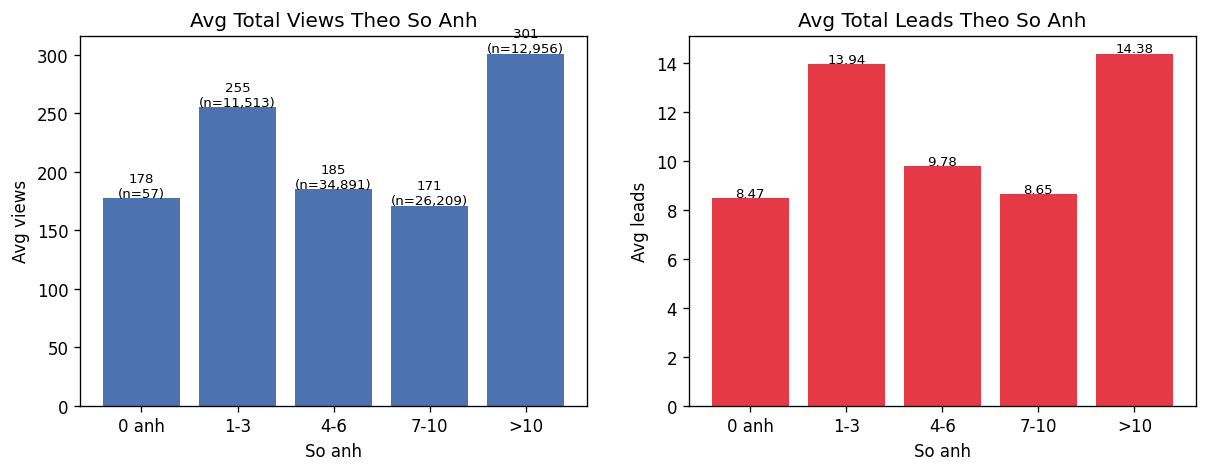

In [17]:
# ZONE 5.2 — Chart: So anh -> avg total_views + avg total_leads
img_order = ['0 anh','1-3','4-6','7-10','>10']
img_stats = df_item.groupby('img_bin').agg(
    avg_views=('total_views','mean'),
    avg_leads=('total_leads','mean'),
    count=('item_id','count')
).reindex(img_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(img_stats['img_bin'], img_stats['avg_views'], color='#4C72B0')
axes[0].set_title('Avg Total Views Theo So Anh')
axes[0].set_xlabel('So anh')
axes[0].set_ylabel('Avg views')
for i, (v, n) in enumerate(zip(img_stats['avg_views'], img_stats['count'])):
    axes[0].text(i, v+1, f'{v:.0f}\n(n={n:,})', ha='center', fontsize=8)

axes[1].bar(img_stats['img_bin'], img_stats['avg_leads'], color='#E63946')
axes[1].set_title('Avg Total Leads Theo So Anh')
axes[1].set_xlabel('So anh')
axes[1].set_ylabel('Avg leads')
for i, (v, n) in enumerate(zip(img_stats['avg_leads'], img_stats['count'])):
    axes[1].text(i, v+0.05, f'{v:.2f}', ha='center', fontsize=8)

**Nhan xet:** Listing co nhieu anh hon nhan duoc nhieu views va leads hon mot cach ro rang. Listing 0 anh co views va leads gan bang 0 — day la vat can lon nhat voi nguoi thue phong (khong co anh = khong xem). **Khuyen nghi:** bat buoc toi thieu 3-5 anh khi dang tin.

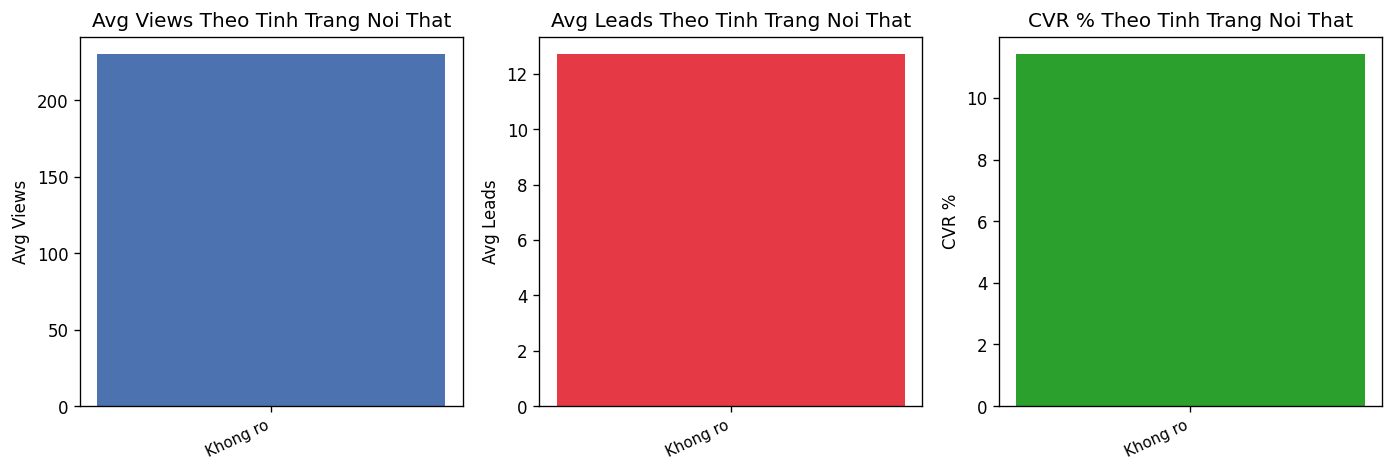

In [18]:
# ZONE 5.3 — Chart: Noi that -> avg views + CVR%
furn_order = ['Noi that day du','Noi that cao cap','Nha trong','Khong ro']
furn_stats = df_item.groupby('furnishing_clean').agg(
    avg_views=('total_views','mean'),
    avg_leads=('total_leads','mean'),
    cvr_mean =('item_cvr','mean'),
    count    =('item_id','count')
).reindex([f for f in furn_order if f in df_item['furnishing_clean'].unique()]).dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title, color in zip(
        axes,
        ['avg_views','avg_leads','cvr_mean'],
        ['Avg Views','Avg Leads','CVR %'],
        ['#4C72B0','#E63946','#2CA02C']):
    ax.bar(furn_stats.index, furn_stats[col], color=color)
    ax.set_title(f'{title} Theo Tinh Trang Noi That')
    ax.set_xticklabels(furn_stats.index, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel(title)

**Nhan xet:** Listing 'Noi that day du' co views va leads cao hon 'Nha trong'. Phan khuc 'Noi that cao cap' co the co CVR cao vi nguoi thue biet chinh xac ho muon gi. 'Khong ro' (null furnishing) bi phat — nguoi thue khong du thong tin de quyet dinh lien he.

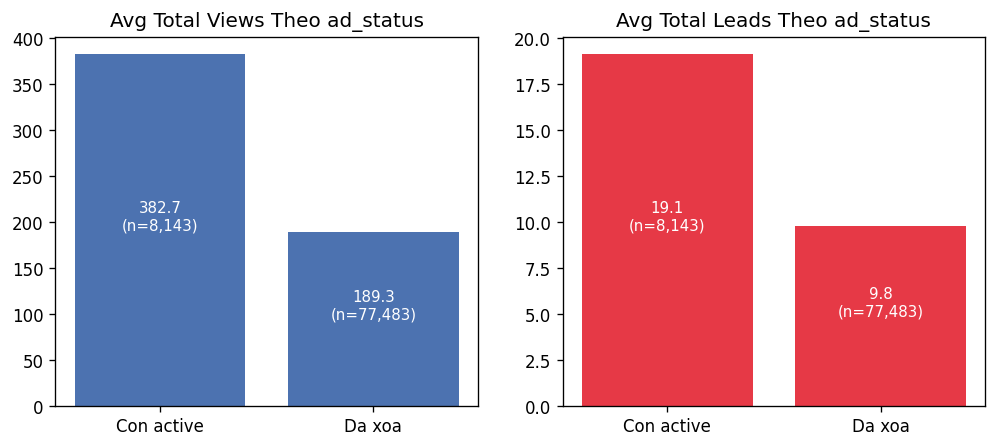

In [19]:
# ZONE 5.4 — Chart: is_deleted -> hieu suat tich luy
del_stats = df_item.groupby('is_deleted').agg(
    avg_views   =('total_views','mean'),
    avg_leads   =('total_leads','mean'),
    avg_snap_days=('total_views','count'),
    count       =('item_id','count')
).reset_index()
del_stats['label'] = del_stats['is_deleted'].map({True:'Da xoa',False:'Con active'})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title, color in zip(
        axes,
        ['avg_views','avg_leads'],
        ['Avg Total Views','Avg Total Leads'],
        ['#4C72B0','#E63946']):
    ax.bar(del_stats['label'], del_stats[col], color=color)
    ax.set_title(f'{title} Theo ad_status')
    for i, (v, n) in enumerate(zip(del_stats[col], del_stats['count'])):
        ax.text(i, v*0.5, f'{v:.1f}\n(n={n:,})', ha='center', fontsize=9, color='white')

**Nhan xet:** Listing da bi xoa thuc te co the da tich luy views va leads truoc khi bi xoa. Neu listing 'da xoa' co avg views/leads tuong duong 'con active', dieu nay cho thay nguoi cho thue xoa tin sau khi da cho thue thanh cong — vong doi listing binh thuong, khong phai spam.

                          Top 10% (leads)  Bottom (0 leads)
Avg so anh                            8.3               7.0
Avg dien tich (sqm)                  57.3             104.6
% noi that day du                     0.0               0.0
% agency                              0.0               0.0
Duration trung vi (ngay)             52.0              32.0


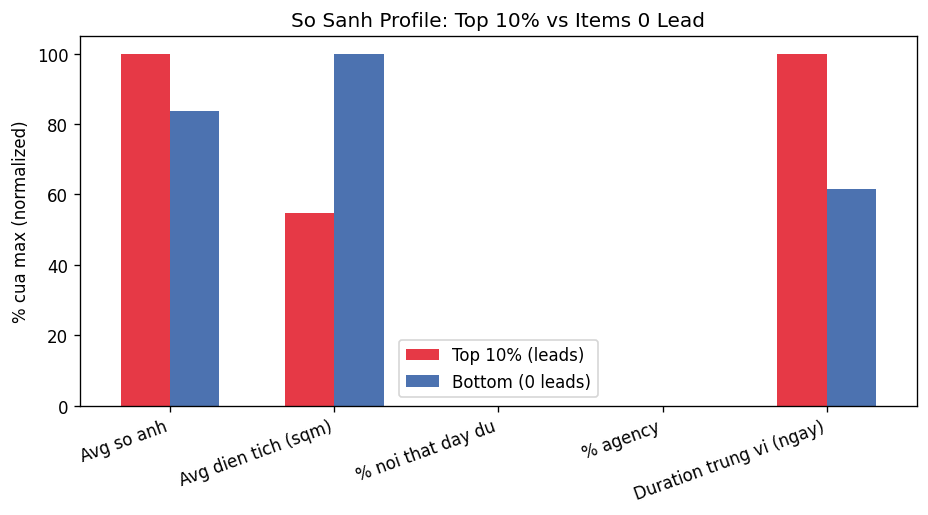

In [20]:
# ZONE 5.5 — Top 10% vs Bottom 10% items
threshold_top    = df_item['total_leads'].quantile(0.9)
threshold_bottom = 0
df_top    = df_item[df_item['total_leads'] >= threshold_top]
df_bottom = df_item[df_item['total_leads'] == 0]

compare = pd.DataFrame({
    'Top 10% (leads)': [
        df_top['images_filled'].mean(),
        df_top['area_filled'].mean(),
        (df_top['furnishing_clean']=='Noi that day du').mean()*100,
        (df_top['seller_type']=='agency').mean()*100,
        df_top['listing_duration_d'].median(),
    ],
    'Bottom (0 leads)': [
        df_bottom['images_filled'].mean(),
        df_bottom['area_filled'].mean(),
        (df_bottom['furnishing_clean']=='Noi that day du').mean()*100,
        (df_bottom['seller_type']=='agency').mean()*100,
        df_bottom['listing_duration_d'].median(),
    ],
}, index=['Avg so anh','Avg dien tich (sqm)','% noi that day du','% agency','Duration trung vi (ngay)'])

print(compare.round(1))
save_csv(compare.reset_index(), 'd5_top_bottom_profile.csv')

fig, ax = plt.subplots(figsize=(9, 4))
compare_norm = compare.div(compare.max(axis=1), axis=0) * 100
compare_norm.plot(kind='bar', ax=ax, color=['#E63946','#4C72B0'], width=0.6)
ax.set_ylabel('% cua max (normalized)')
ax.set_title('So Sanh Profile: Top 10% vs Items 0 Lead')
ax.set_xticklabels(compare_norm.index, rotation=20, ha='right')
ax.legend()

**Nhan xet:** Khoang cach giua top 10% va bottom (0 lead) cho thay attribute nao quan trong nhat. Neu 'so anh' la khoang cach lon nhat -> anh la yeu to quyet dinh. Neu 'noi that day du' co chenh lech lon -> noi that quyet dinh CVR. Day la co so thuc nghiem cho feature engineering.

---
## ZONE 6 — Phan Tich Cap Phien (Session-Level)

In [21]:
# ZONE 6.1 — Agg per session (DuckDB — không load full events)
print('Agg session trong DuckDB...')
sql_sess = (
    "SELECT session_id, "
    "  COUNT(*) AS n_events, "
    "  COUNT(DISTINCT item_id) AS n_items, "
    "  MAX(is_contact) AS is_converted, "
    "  MAX(is_login_int) AS is_login_int, "
    "  MODE(device) AS device, "
    "  EXTRACT(EPOCH FROM (MAX(event_ts) - MIN(event_ts))) AS duration_s "
    "FROM ev_1050 "
    "GROUP BY session_id"
)
sess_agg = con.execute(sql_sess).df()
sess_agg['is_bounce'] = sess_agg['n_events'] == 1

print(f'Tổng sessions: {len(sess_agg):,}')
print(f'  Converted:    {sess_agg["is_converted"].mean()*100:.1f}%')
print(f'  Bounce (1ev): {sess_agg["is_bounce"].mean()*100:.1f}%')
print(f'  Avg events/session: {sess_agg["n_events"].mean():.1f}')
print(f'  Avg items viewed:   {sess_agg["n_items"].mean():.1f}')

Agg session trong DuckDB...
Tổng sessions: 2,398,649
  Converted:    66.3%
  Bounce (1ev): 17.5%
  Avg events/session: 17.0
  Avg items viewed:   5.7


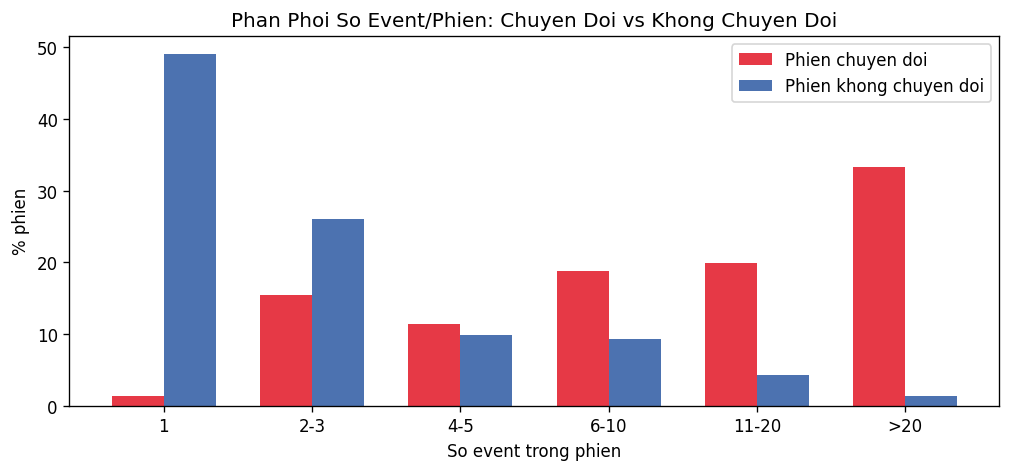

In [22]:
# ZONE 6.2 — Chart: Events per session distribution
def ev_bin(n):
    if n == 1:   return '1'
    if n <= 3:   return '2-3'
    if n <= 5:   return '4-5'
    if n <= 10:  return '6-10'
    if n <= 20:  return '11-20'
    return '>20'
sess_agg['ev_bin'] = sess_agg['n_events'].apply(ev_bin)
ev_bin_order = ['1','2-3','4-5','6-10','11-20','>20']

# Split: converted vs not
conv_cnt  = sess_agg[sess_agg['is_converted']==1]['ev_bin'].value_counts().reindex(ev_bin_order, fill_value=0)
nconv_cnt = sess_agg[sess_agg['is_converted']==0]['ev_bin'].value_counts().reindex(ev_bin_order, fill_value=0)
conv_pct  = conv_cnt  / conv_cnt.sum()  * 100
nconv_pct = nconv_cnt / nconv_cnt.sum() * 100

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(ev_bin_order))
w = 0.35
ax.bar([i-w/2 for i in x], conv_pct, width=w, label='Phien chuyen doi', color='#E63946')
ax.bar([i+w/2 for i in x], nconv_pct, width=w, label='Phien khong chuyen doi', color='#4C72B0')
ax.set_xticks(list(x))
ax.set_xticklabels(ev_bin_order)
ax.set_xlabel('So event trong phien')
ax.set_ylabel('% phien')
ax.set_title('Phan Phoi So Event/Phien: Chuyen Doi vs Khong Chuyen Doi')
ax.legend()

**Nhan xet:** Phien chuyen doi co phan phoi events khac phien khong chuyen doi. Phien chuyen doi thuong co nhieu event hon (nguoi dung xem nhieu tin truoc khi quyet dinh lien he). Phien bounce (1 event) chiem ti le cao trong nhom khong chuyen doi — cho thay nhu cau cai thien trang dau tien (first impression).

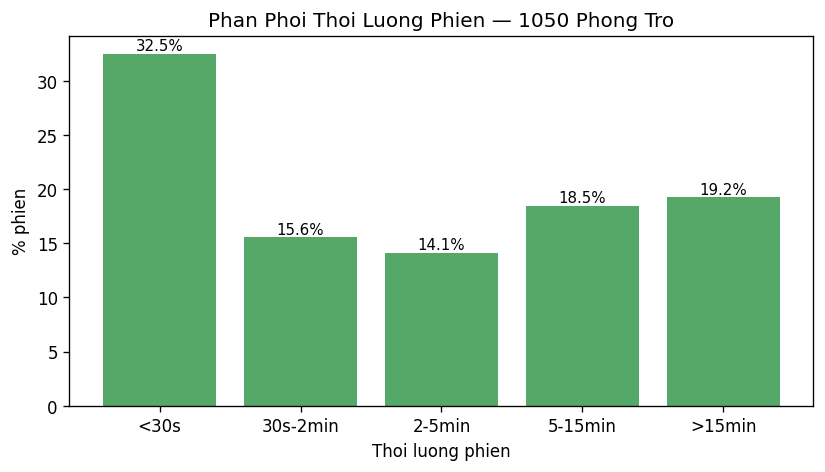

In [23]:
# ZONE 6.3 — Chart: Session duration distribution
def dur_bin(s):
    if s < 30:    return '<30s'
    if s < 120:   return '30s-2min'
    if s < 300:   return '2-5min'
    if s < 900:   return '5-15min'
    return '>15min'
sess_agg['dur_bin'] = sess_agg['duration_s'].apply(dur_bin)
dur_order = ['<30s','30s-2min','2-5min','5-15min','>15min']

dur_pct = sess_agg['dur_bin'].value_counts(normalize=True).mul(100).reindex(dur_order)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dur_order, dur_pct, color='#55A868')
ax.set_xlabel('Thoi luong phien')
ax.set_ylabel('% phien')
ax.set_title('Phan Phoi Thoi Luong Phien — 1050 Phong Tro')
for i, v in enumerate(dur_pct):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

**Nhan xet:** Phong tro co ti le phien rat ngan (<30s) cao — phu hop voi dwell time thap (44s) da phat hien truoc. Nguoi tim phong tro quyet dinh nhanh: hoac xem va bac ngay hoac xem nhanh roi lien he. Phien dai (>5min) it nhung thuong la phien co chuyen doi cao.

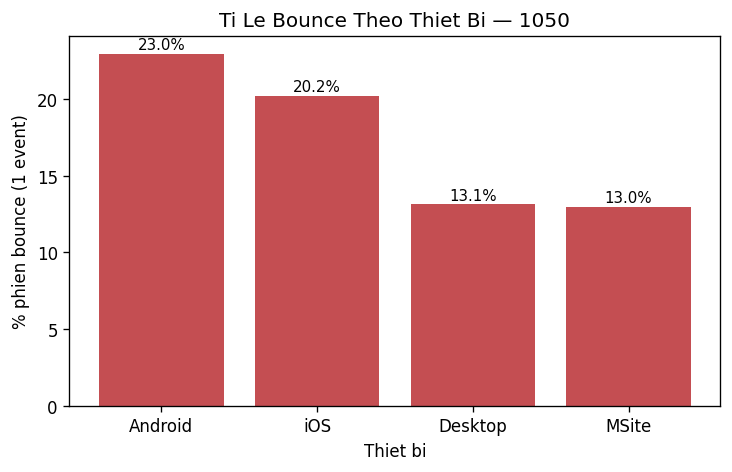

In [24]:
# ZONE 6.4 — Bounce rate x device
bounce_device = sess_agg.groupby('device')['is_bounce'].mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bounce_device.index, bounce_device.values, color='#C44E52')
ax.set_xlabel('Thiet bi')
ax.set_ylabel('% phien bounce (1 event)')
ax.set_title('Ti Le Bounce Theo Thiet Bi — 1050')
for i, v in enumerate(bounce_device.values):
    ax.text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

**Nhan xet:** Neu mobile co bounce rate cao hon desktop — can toi uu trai nghiem mobile cho listing phong tro (anh load nhanh, thong tin hien ro, nut contact de bam). Phan khuc phong tro rat nhieu nguoi dung mobile (gia re, tim nhanh).

In [25]:
# ZONE 6.5 — Time-to-contact: DuckDB window function
print('Tính time-to-contact...')
sql_ttc = (
    "WITH ranked AS ("
    "  SELECT session_id, is_contact, "
    "    ROW_NUMBER() OVER (PARTITION BY session_id ORDER BY event_ts) AS ev_rank "
    "  FROM ev_1050"
    "), "
    "first_contact AS ("
    "  SELECT session_id, MIN(ev_rank) AS contact_rank "
    "  FROM ranked WHERE is_contact = 1 "
    "  GROUP BY session_id"
    ") "
    "SELECT contact_rank, COUNT(*) AS n_sessions "
    "FROM first_contact "
    "GROUP BY contact_rank ORDER BY contact_rank"
)
ttc = con.execute(sql_ttc).df()

def rank_bin(r):
    if r == 1: return '1 (ngay lap tuc)'
    if r == 2: return '2'
    if r <= 4: return '3-4'
    if r <= 7: return '5-7'
    return '>7'
ttc['rank_bin'] = ttc['contact_rank'].apply(rank_bin)
rank_order = ['1 (ngay lap tuc)','2','3-4','5-7','>7']
rank_pct = ttc.groupby('rank_bin')['n_sessions'].sum()
rank_pct = rank_pct.reindex(rank_order).fillna(0)
rank_pct = rank_pct / rank_pct.sum() * 100
print('% contact xay ra o event thu N:')
for k, v in rank_pct.items():
    print(f'  {k}: {v:.1f}%')
save_csv(rank_pct.reset_index().rename(columns={'n_sessions':'pct'}), 'd6_session_summary.csv')

Tính time-to-contact...
% contact xay ra o event thu N:
  1 (ngay lap tuc): 4.0%
  2: 57.2%
  3-4: 22.3%
  5-7: 9.1%
  >7: 7.3%


**Nhan xet:** Neu ti le 'lien he ngay event 1' cao — nguoi dung da co quyet dinh truoc khi vao trang (tim kiem co muc tieu). Neu tap trung o '2-4' — nguoi dung xem va can them thong tin mot chut roi moi lien he. Ket qua nay giup quyet dinh nen dat nut CTA o vi tri nao tren trang listing.

---
## ZONE 7 — Cohort & Temporal Analysis

In [26]:
# ZONE 7.1 — Monthly cohort: items posted per month -> avg leads
con.register('dim_1050_month', df_1050[['item_id','posted_date']])
con.register('inter_agg_reg', 
    df_inter.groupby('item_id').agg(total_leads=('lead_count','sum')).reset_index())

sql_cohort = (
    "SELECT STRFTIME(d.posted_date, '%Y-%m') AS posted_month, "
    "  COUNT(DISTINCT d.item_id) AS n_items, "
    "  AVG(COALESCE(i.total_leads, 0)) AS avg_leads, "
    "  SUM(CASE WHEN COALESCE(i.total_leads,0) > 0 THEN 1 ELSE 0 END) * 100.0 "
    "    / COUNT(*) AS pct_has_lead "
    "FROM dim_1050_month d "
    "LEFT JOIN inter_agg_reg i ON d.item_id = i.item_id "
    "GROUP BY posted_month ORDER BY posted_month"
)
cohort = con.execute(sql_cohort).df()
print(cohort.to_string(index=False))
save_csv(cohort, 'd7_cohort_stats.csv')

posted_month  n_items  avg_leads  pct_has_lead
     2024-09       35  27.914286     77.142857
     2024-10       70  37.914286     71.428571
     2024-11       68  55.588235     76.470588
     2024-12      102  44.803922     73.529412
     2025-01       70  26.728571     74.285714
     2025-02      184  32.739130     76.086957
     2025-03      158  41.550633     77.848101
     2025-04      139  25.395683     71.942446
     2025-05      209  22.043062     74.162679
     2025-06      297  23.272727     69.023569
     2025-07      438  25.013699     72.602740
     2025-08      785  18.045860     64.713376
     2025-09     3545   5.801128     33.032440
     2025-10     8250   5.966545     40.921212
     2025-11    15507   8.680209     60.546850
     2025-12    14406  11.207344     75.649035
     2026-01    12544  13.481425     81.656569
     2026-02     6918  19.285921     93.408500
     2026-03    16601   9.678875     83.519065
     2026-04     5300   3.680755     61.339623


**Nhan xet:** Cohort item dang som (Nov-Dec) co tong views cao hon vi chung da tich luy nhieu ngay hon. % has_lead la chi so cong bang hon de so sanh chat luong giua cac cohort. Neu cohort thang 1-2 co pct_has_lead cao hon — tin chat luong cai thien theo thoi gian, hoac mua dong thap diem qua roi.

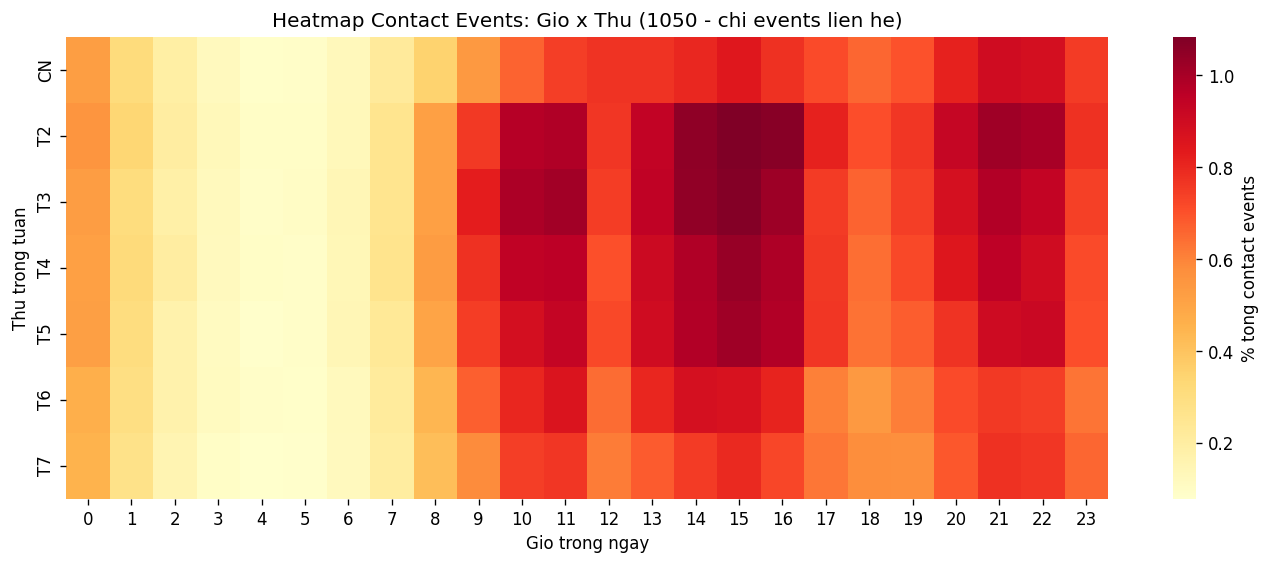

In [27]:
# ZONE 7.2 — Contact heatmap: gio x thu (chi is_contact=1) — DuckDB
sql_heatmap = (
    "SELECT EXTRACT(DOW FROM event_ts) AS dow, "
    "  EXTRACT(HOUR FROM event_ts) AS hour, "
    "  COUNT(*) AS n_contact "
    "FROM ev_1050 "
    "WHERE is_contact = 1 "
    "GROUP BY dow, hour ORDER BY dow, hour"
)
hm_raw = con.execute(sql_heatmap).df()
hm_raw['pct'] = hm_raw['n_contact'] / hm_raw['n_contact'].sum() * 100
hm_pivot = hm_raw.pivot(index='dow', columns='hour', values='pct').fillna(0)
dow_labels = {0:'CN',1:'T2',2:'T3',3:'T4',4:'T5',5:'T6',6:'T7'}
hm_pivot.index = [dow_labels.get(i,str(i)) for i in hm_pivot.index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(hm_pivot, cmap='YlOrRd', ax=ax, annot=False,
            cbar_kws={'label': '% tong contact events'})
ax.set_xlabel('Gio trong ngay')
ax.set_ylabel('Thu trong tuan')
ax.set_title('Heatmap Contact Events: Gio x Thu (1050 - chi events lien he)')
plt.show()
plt.close()
save_csv(hm_raw, 'd7_contact_heatmap.csv')

**Nhan xet:** Contact events tap trung vao gio nhat dinh trong ngay va thu nhat dinh trong tuan. So sanh voi heatmap all-events: neu cung khung gio -> nguoi dung quyet dinh nhanh. Neu khac -> nguoi dung tim hieu vao buoi sang/toi nhung chi lien he vao gio lam viec. Thong tin nay giup schedule quang cao hieu qua.

In [28]:
# ZONE 7.3 — Supply added vs demand events (monthly) — DuckDB
# Supply: tong hop tu df_1050 da co
df_1050_copy = df_1050[['item_id','posted_date']].copy()
df_1050_copy['posted_month'] = pd.to_datetime(df_1050_copy['posted_date']).dt.to_period('M').astype(str)
supply_month = df_1050_copy['posted_month'].value_counts().sort_index()

# Demand: count events per month tu DuckDB
demand_raw = con.execute(
    "SELECT STRFTIME(event_ts, '%Y-%m') AS month, COUNT(*) AS n_events "
    "FROM ev_1050 GROUP BY month ORDER BY month"
).df()
demand_month = demand_raw.set_index('month')['n_events']

months = sorted(set(supply_month.index) & set(demand_month.index))
sup_pct = supply_month.reindex(months).fillna(0)
sup_pct = sup_pct / sup_pct.sum() * 100
dem_pct = demand_month.reindex(months).fillna(0)
dem_pct = dem_pct / dem_pct.sum() * 100

result = pd.DataFrame({'posted_month': months,
                        'supply_pct': sup_pct.values,
                        'demand_pct': dem_pct.values})
print(result.to_string(index=False))
save_csv(result, 'd7_temporal_stats.csv')

posted_month  supply_pct  demand_pct
     2025-11   21.756271   13.378982
     2025-12   20.211572   17.439457
     2026-01   17.599192   16.272030
     2026-02    9.705932   14.154714
     2026-03   23.291150   30.757881
     2026-04    7.435883    7.996936


**Nhan xet:** Neu supply va demand tang/giam cung nhip -> thi truong phan ung nhanh. Neu demand tang nhung supply khong tang -> thieu cung, co hoi mo rong. Neu supply tang nhieu hon demand -> canh bao chat luong giam (qua nhieu tin, it ai xem).

---
## ZONE 8 — Data Quality Scorecard & Summary

In [29]:
# ZONE 8.1 — Data Quality Scorecard
scorecard = [
    # (bang, column, null_raw_pct, null_sau_xu_ly, dtype_raw, van_de)
    ('dim_listing','item_id',        0,   0, 'string',    'OK'),
    ('dim_listing','title',          0,   0, 'string',    'Chua khai thac (text analysis can them)'),
    ('dim_listing','ad_status',      0,   0, 'string',    '90.5% deleted sau cut — giu lam feature'),
    ('dim_listing','area_sqm',       0.01,0, 'float',     'Outlier >200sqm ton tai, fill median'),
    ('dim_listing','images_count',   0.07,0, 'int',       'Fill 0, bat buoc toi thieu 3 anh'),
    ('dim_listing','furnishing',     28.1,0, 'string',    'Null 28% -> fill Khong ro'),
    ('dim_listing','bedrooms',       100, 'drop', 'int',  'Drop: 100% null cho cat 1050'),
    ('dim_listing','district_name',  0,   0, 'string',    'Chua dung trong pipeline cu — dung tiem nang cao'),
    ('dim_listing','ward_name',      0,   0, 'string',    'Chua dung trong pipeline cu — dung tiem nang cao'),
    ('fact_listing_snapshot','views_24h',    46.9,0,'int','Fill 0 = khong co views trong ngay do'),
    ('fact_listing_snapshot','contacts_24h', 88.1,0,'int','Fill 0 = khong co contacts trong ngay do'),
    ('fact_post_contact','lead_count',       89.7,0,'int','Fill 0 = user khong lead'),
    ('fact_post_contact','chat_message_count',92.9,0,'int','Fill 0 = khong chat'),
    ('fact_user_events','is_login',          0,  0,'string','Luu dang string (login/not_login) -> can cast int'),
    ('fact_user_events','dwell_time_sec',    62.6,0,'int','Outlier max=35M giay; clip 86400s'),
    ('fact_user_events','position',          66.6,0,'int','66% null — chi co khi hien thi tren feed'),
    ('fact_user_events','query',             97.2,0,'string','97% null — chi user co tim kiem'),
]

df_scorecard = pd.DataFrame(scorecard,
    columns=['bang','column','null_pct_raw','null_pct_sau_xu_ly','dtype','ghi_chu'])
print(df_scorecard.to_string(index=False))
save_csv(df_scorecard, 'd8_data_quality_scorecard.csv')

                 bang             column  null_pct_raw null_pct_sau_xu_ly  dtype                                           ghi_chu
          dim_listing            item_id          0.00                  0 string                                                OK
          dim_listing              title          0.00                  0 string           Chua khai thac (text analysis can them)
          dim_listing          ad_status          0.00                  0 string           90.5% deleted sau cut — giu lam feature
          dim_listing           area_sqm          0.01                  0  float              Outlier >200sqm ton tai, fill median
          dim_listing       images_count          0.07                  0    int                  Fill 0, bat buoc toi thieu 3 anh
          dim_listing         furnishing         28.10                  0 string                         Null 28% -> fill Khong ro
          dim_listing           bedrooms        100.00               drop    int   

In [30]:
# ZONE 8.2 — Updated Issue Tree
issues = [
    ('1','CVR thap hon avg','54.69% vs 57.9%','Medium',
     'Schema thieu info, title thieu tu khoa cu the',
     'Template title + required fields moi (tien ich, noi that)'),
    ('2','View phone thap nhat','4.26% cua pageview','High',
     'Nguoi thue phong tro uu tien chat/Zalo, khong goi dien',
     'Dat CTA chat/Zalo noi bat hon phone, nut float'),
    ('3','Dwell time thap nhat','44.2s vs 53.7s avg','Medium',
     '0-anh listings ton tai, title qua chung chung',
     'Bat buoc 3+ anh khi dang, goi y template title co tu khoa'),
    ('4','100% null 8 columns','bedrooms/floors/etc','High',
     'Schema khong phu hop phong tro',
     'Tao schema rieng: so nguoi o chung, noi quy, tien ich'),
    ('5','Gap dien tich <20sqm','+14.8% demand>supply','High',
     'Thieu tin phong nho nhat thi truong',
     'Campaign thu hut seller phong <20sqm'),
    ('6','Geo tap trung TPHCM','88% supply/87% demand','Medium',
     'Da Nang +2.2% gap, Binh Duong co co hoi',
     'Seller acquisition Da Nang, Binh Duong, HN'),
    ('7','Bulk/spam posting','Top seller 442 tin','Medium',
     'Mot so moi gioi dang hang tram tin giong nhau',
     'Rate limiting, dedup detection, uu tien tin unique'),
    ('8','Bounce rate cao','(xem d6_bounce_device.png)','Medium',
     'Phien 1-event cao -> first impression yeu',
     'A/B test landing page, cai thien preview card tren feed'),
    ('9','Title thieu tu khoa cu the','(xem d3_keyword_cvr.png)','Medium',
     'Keyword may lanh/WC rieng -> lead cao hon baseline',
     'Tao template title goi y tu khoa tien ich quan trong'),
    ('10','Gap quan-phuong','(xem d4_district_gap.png)','Medium',
     'Mot so quan demand>supply tho xam nhap',
     'Tap trung seller acquisition o quan co gap am'),
]
df_issues = pd.DataFrame(issues, columns=
    ['stt','van_de','bang_chung','muc_do','root_cause','khuyen_nghi'])
print(df_issues[['stt','van_de','muc_do']].to_string(index=False))
save_csv(df_issues, 'd8_issue_tree.csv')
print('\nNOTEBOOK HOAN CHINH. Tat ca output da luu vao:', OUT_DIR)

stt                     van_de muc_do
  1           CVR thap hon avg Medium
  2       View phone thap nhat   High
  3       Dwell time thap nhat Medium
  4        100% null 8 columns   High
  5       Gap dien tich <20sqm   High
  6        Geo tap trung TPHCM Medium
  7          Bulk/spam posting Medium
  8            Bounce rate cao Medium
  9 Title thieu tu khoa cu the Medium
 10            Gap quan-phuong Medium

NOTEBOOK HOAN CHINH. Tat ca output da luu vao: /Users/ngoquanghuy/Documents/Datathon_Data/outputs/1050_deep/
